# 04 - Anomaly Detection

## Imports

In [1]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## Reporting the Gap Instead of Guessing

`ai_resources/agent_primer/08-guardrails-failure-modes-and-eval.md` said a well-built agent should be tested by feeding it *"deliberately malformed or missing data... and confirm it reports the gap instead of guessing."* That guidance assumed something this notebook actually builds: a concrete way to notice that a piece of data doesn't fit the pattern in the first place, rather than a vague instinct to "be careful." Two techniques, from simplest to most general.

## Simple and Effective: Z-Scores

For a single number, the simplest anomaly check is how many standard deviations away from the mean it falls - its **z-score**. A scouted team's `climb_rate` should be fairly consistent match to match; an entry wildly outside that range is either a scouting mistake or something genuinely unusual worth flagging for a human to check.

In [2]:
rng = np.random.default_rng(1515)
climb_readings = rng.normal(0.85, 0.05, 29)
climb_readings = np.append(climb_readings, -0.3)   # one clearly bad scouting entry -
                                                     # climb_rate can't actually be negative

mean, std = climb_readings.mean(), climb_readings.std()
z_scores = (climb_readings - mean) / std

threshold = 3
anomalies = np.abs(z_scores) > threshold
print(f"Flagged {anomalies.sum()} anomaly out of {len(climb_readings)} readings")
print(f"Flagged value(s): {climb_readings[anomalies]}")
print(f"Flagged z-score(s): {z_scores[anomalies].round(2)}")

Flagged 1 anomaly out of 30 readings
Flagged value(s): [-0.3]
Flagged z-score(s): [-5.24]


This is fast, interpretable, and correct here - but it only works one feature at a time, and only catches values that are extreme *along a single axis*. A scouting entry can be perfectly normal on every individual feature and still be a genuinely strange *combination* - a team with both an unusually high climb rate and an unusually high auto score at once, say, even if neither number alone looks extreme. Z-scores, checked independently, would miss that entirely.

## A More General Approach: Reconstruction Error

Recall `03-autoencoders.ipynb`: an autoencoder trained on real team data learns to reconstruct the *patterns* that data actually follows - which features tend to move together, what combinations are typical. A team whose stats fit those patterns reconstructs cleanly, with low error. A team whose stats don't fit *any* pattern the autoencoder learned - even if no single feature looks extreme - reconstructs poorly, because the network has nowhere to map it that round-trips back out cleanly. High **Reconstruction Error** becomes the **Anomaly Score**.

In [3]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def build_autoencoder(input_dim, hidden_dim, bottleneck_dim):
    return {
        'W1_enc': np.random.randn(hidden_dim, input_dim) * (1 / np.sqrt(input_dim)),
        'b1_enc': np.zeros((hidden_dim, 1)),
        'W2_enc': np.random.randn(bottleneck_dim, hidden_dim) * (1 / np.sqrt(hidden_dim)),
        'b2_enc': np.zeros((bottleneck_dim, 1)),
        'W1_dec': np.random.randn(hidden_dim, bottleneck_dim) * (1 / np.sqrt(bottleneck_dim)),
        'b1_dec': np.zeros((hidden_dim, 1)),
        'W2_dec': np.random.randn(input_dim, hidden_dim) * (1 / np.sqrt(hidden_dim)),
        'b2_dec': np.zeros((input_dim, 1)),
    }

def autoencoder_forward(X, p):
    z1_enc = p['W1_enc'] @ X + p['b1_enc']
    a1_enc = relu(z1_enc)
    bottleneck = p['W2_enc'] @ a1_enc + p['b2_enc']
    z1_dec = p['W1_dec'] @ bottleneck + p['b1_dec']
    a1_dec = relu(z1_dec)
    output = p['W2_dec'] @ a1_dec + p['b2_dec']
    return z1_enc, a1_enc, bottleneck, z1_dec, a1_dec, output

def train_autoencoder(X, p, learning_rate=0.05, n_epochs=5000):
    n = X.shape[1]
    for _ in range(n_epochs):
        z1_enc, a1_enc, bottleneck, z1_dec, a1_dec, output = autoencoder_forward(X, p)
        d_output = 2 * (output - X) / n
        d_W2_dec = d_output @ a1_dec.T
        d_b2_dec = np.sum(d_output, axis=1, keepdims=True)
        d_a1_dec = p['W2_dec'].T @ d_output
        d_z1_dec = d_a1_dec * relu_derivative(z1_dec)
        d_W1_dec = d_z1_dec @ bottleneck.T
        d_b1_dec = np.sum(d_z1_dec, axis=1, keepdims=True)
        d_bottleneck = p['W1_dec'].T @ d_z1_dec
        d_W2_enc = d_bottleneck @ a1_enc.T
        d_b2_enc = np.sum(d_bottleneck, axis=1, keepdims=True)
        d_a1_enc = p['W2_enc'].T @ d_bottleneck
        d_z1_enc = d_a1_enc * relu_derivative(z1_enc)
        d_W1_enc = d_z1_enc @ X.T
        d_b1_enc = np.sum(d_z1_enc, axis=1, keepdims=True)
        p['W2_dec'] -= learning_rate * d_W2_dec; p['b2_dec'] -= learning_rate * d_b2_dec
        p['W1_dec'] -= learning_rate * d_W1_dec; p['b1_dec'] -= learning_rate * d_b1_dec
        p['W2_enc'] -= learning_rate * d_W2_enc; p['b2_enc'] -= learning_rate * d_b2_enc
        p['W1_enc'] -= learning_rate * d_W1_enc; p['b1_enc'] -= learning_rate * d_b1_enc

def reconstruction_error(x_row, p):
    x_col = x_row.reshape(-1, 1)
    _, _, _, _, _, output = autoencoder_forward(x_col, p)
    return np.sum((output.flatten() - x_row) ** 2)

In [4]:
def make_group(climb_center, auto_center, n, rng):
    climb_rate = rng.normal(climb_center, 0.08, n)
    auto_score = rng.normal(auto_center, 0.4, n)
    endgame_reliability = climb_rate * 0.9 + rng.normal(0, 0.05, n)
    cycle_speed = auto_score * 0.7 + rng.normal(0, 0.3, n)
    return np.column_stack([climb_rate, auto_score, endgame_reliability, cycle_speed])

rng_teams = np.random.default_rng(1515)
n_per_group = 15
teams = np.vstack([
    make_group(0.85, 1.5, n_per_group, rng_teams),
    make_group(0.15, 4.5, n_per_group, rng_teams),
    make_group(0.5, 2.8, n_per_group, rng_teams),
])
feature_mean, feature_std = teams.mean(axis=0), teams.std(axis=0)
teams_scaled = (teams - feature_mean) / feature_std

# a scouting entry with high climb AND high auto at once - not extreme on either
# single feature by real-world standards, but a combination this dataset's normal
# teams never actually show together
anomalous_entry_raw = np.array([0.9, 4.8, 0.85, 3.5])
anomalous_entry_scaled = (anomalous_entry_raw - feature_mean) / feature_std

params = build_autoencoder(input_dim=4, hidden_dim=8, bottleneck_dim=2)
train_autoencoder(teams_scaled.T, params)

normal_errors = np.array([
    reconstruction_error(teams_scaled[i], params) for i in range(len(teams_scaled))
])
anomaly_error = reconstruction_error(anomalous_entry_scaled, params)

print(f"Normal teams' reconstruction error: min={normal_errors.min():.4f}, "
      f"max={normal_errors.max():.4f}, mean={normal_errors.mean():.4f}")
print(f"Anomalous entry's reconstruction error: {anomaly_error:.4f}")

Normal teams' reconstruction error: min=0.0011, max=0.3225, mean=0.0513
Anomalous entry's reconstruction error: 6.9655


Threshold (mean + 3 std of normal errors): 0.2393
Anomalous entry flagged: True


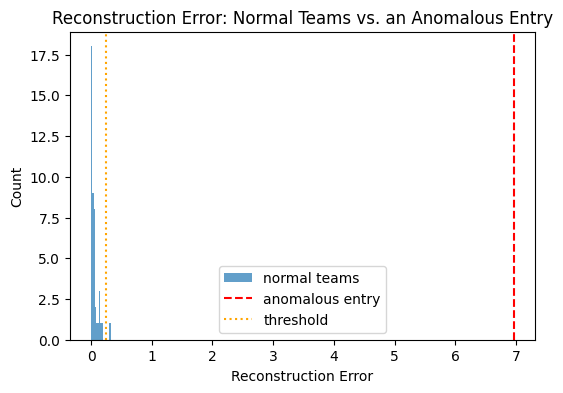

In [5]:
anomaly_threshold = normal_errors.mean() + 3 * normal_errors.std()
print(f"Threshold (mean + 3 std of normal errors): {anomaly_threshold:.4f}")
print(f"Anomalous entry flagged: {anomaly_error > anomaly_threshold}")

plt.figure(figsize=(6, 4))
plt.hist(normal_errors, bins=15, alpha=0.7, label='normal teams')
plt.axvline(anomaly_error, color='red', linestyle='--', label='anomalous entry')
plt.axvline(anomaly_threshold, color='orange', linestyle=':', label='threshold')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.title('Reconstruction Error: Normal Teams vs. an Anomalous Entry')
plt.legend()
plt.show()

The anomalous entry's reconstruction error should be dramatically higher than any normal team's - not because any single feature was individually extreme, but because the *combination* doesn't fit the pattern the autoencoder learned from real data. This is exactly the kind of check `agent_primer/08` asked for: a concrete signal an agent could use to say "this scouting entry looks wrong" instead of quietly treating it as normal, and it's just as applicable to noticing a team's in-match stats have suddenly stopped looking like their own scouted baseline - a real robot malfunction, not a strategy change - as it is to catching a data-entry mistake.

## Try It Yourself

Generate 5 more "normal" teams from the existing three archetypes (reuse `make_group`) and 2 more genuinely anomalous entries with different unusual feature combinations than the one above. Compute reconstruction error for all of them and check: does the same `mean + 3 * std` threshold (computed from the *original* normal teams only, not refit on the new data) correctly separate the new normal teams from the new anomalies? If a false positive or false negative shows up, is it because the threshold was wrong, or because the new anomaly happened to be less unusual than the original one?

In [6]:
# TODO: generate 5 more normal teams and 2 more anomalous entries with different
# unusual feature combinations, compute their reconstruction errors, and check
# whether the original anomaly_threshold still separates them correctly


## Resources

- Chandola, V., Banerjee, A., & Kumar, V. (2009). "Anomaly Detection: A Survey." *ACM Computing Surveys*. A broad overview of anomaly detection techniques, including both the statistical and reconstruction-based families covered above (paper).
- Sakurada, M. & Yairi, T. (2014). "Anomaly Detection Using Autoencoders with Nonlinear Dimensionality Reduction." The paper formalizing reconstruction-error-based anomaly detection with autoencoders, exactly as built above (paper).